In [51]:
import os
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [52]:
images_path = 'data/images'
annotations_file = 'data/images/_annotations.txt'
classes_file = 'data/images/_classes.txt'

In [53]:
# Load class labels
with open(classes_file, 'r') as f:
    class_names = [line.strip() for line in f.readlines()]

In [54]:
def parse_annotation_line(line):
    parts = line.strip().split()
    image_name = parts[0]
    annotations = []
    
    for item in parts[1:]:
        x1, y1, x2, y2, class_id = map(int, item.split(','))
        annotations.append({
            'image': image_name,
            'x1': x1,
            'y1': y1,
            'x2': x2,
            'y2': y2,
            'class_id': class_id,
            'class_name': class_names[class_id] if class_id < len(class_names) else 'unknown'
        })
        
    return annotations

In [55]:
# Parse all lines
all_annotations = []
with open(annotations_file, 'r') as f:
    for line in f:
        parsed = parse_annotation_line(line)
        all_annotations.extend(parsed)

df = pd.DataFrame(all_annotations)
df.head()

,image,x1,y1,x2,y2,class_id,class_name
0,9999945_00000_d_0000165_jpg.rf.b66333ba0c8a385...,247,384,294,440,3,car
1,9999945_00000_d_0000165_jpg.rf.b66333ba0c8a385...,172,365,223,424,3,car
2,9999945_00000_d_0000165_jpg.rf.b66333ba0c8a385...,314,523,380,617,3,car
3,9999945_00000_d_0000165_jpg.rf.b66333ba0c8a385...,89,270,129,320,3,car
4,9999945_00000_d_0000165_jpg.rf.b66333ba0c8a385...,48,225,84,274,3,car


In [56]:
df['class_id'].unique()

array([ 3, 11,  4,  7, 10,  8,  5,  2,  6,  0,  9,  1])

In [57]:
df.shape

(471190, 7)

In [58]:
df['image'].nunique()

8626

In [59]:
def show_image_with_boxes(image_id):
    img_path = os.path.join(images_path, image_id)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    annots = df[df['image'] == image_id]

    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    ax = plt.gca()

    for _, row in annots.iterrows():
        rect = Rectangle((row['x1'], row['y1']),
                         row['x2'] - row['x1'],
                         row['y2'] - row['y1'],
                         linewidth=2,
                         edgecolor='red',
                         facecolor='none')
        ax.add_patch(rect)
        plt.text(row['x1'], row['y1'] - 5, row['class_name'], color='white', fontsize=12, backgroundcolor='red')

    plt.axis('off')
    plt.title(image_id)
    plt.show()

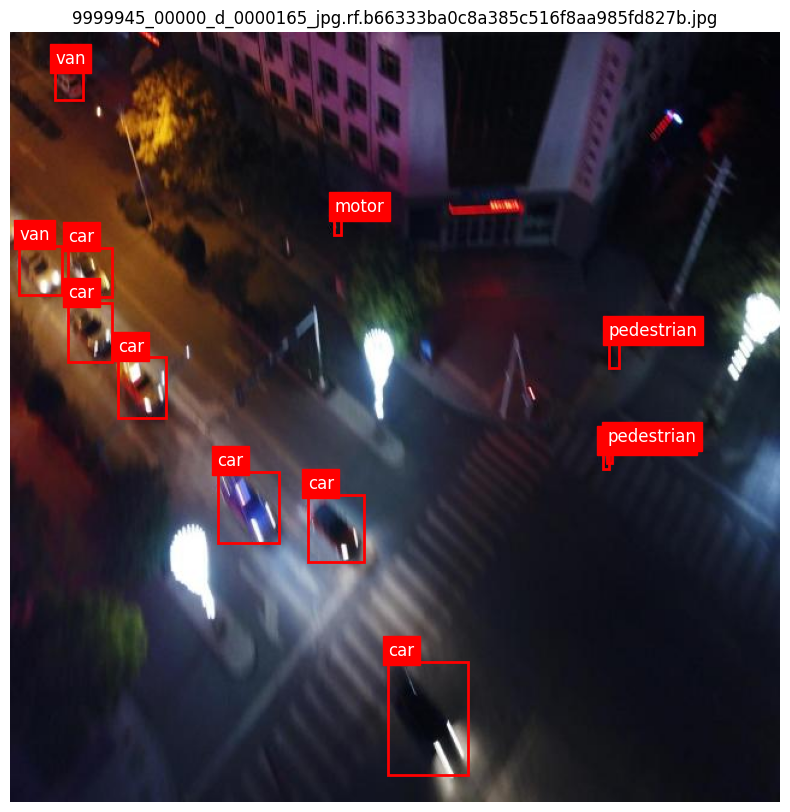

In [60]:
sample_image = df['image'].iloc[0]
show_image_with_boxes(sample_image)

In [61]:
labels_dir = os.path.join('labels')
os.makedirs(labels_dir, exist_ok=True)

img_width, img_height = 640, 640 

for image_name, group in df.groupby('image'):
    label_lines = []
    for _, row in group.iterrows():

        xc = (row.x1 + row.x2) / 2.0
        yc = (row.y1 + row.y2) / 2.0
        w  = (row.x2 - row.x1)
        h  = (row.y2 - row.y1)

        xc_norm = xc / img_width
        yc_norm = yc / img_height
        w_norm  = w  / img_width
        h_norm  = h  / img_height

        label_lines.append(f"{row.class_id} {xc_norm:.6f} {yc_norm:.6f} {w_norm:.6f} {h_norm:.6f}")
    
    label_path = os.path.join(labels_dir, os.path.splitext(image_name)[0] + '.txt')
    with open(label_path, 'w') as f:
        f.write('\n'.join(label_lines))


In [12]:
import cv2

In [13]:
cfg_path       = "yolo3\yolov3.cfg"
weights_path   = "yolo3\yolov3.weights"
classes_path   = "yolo3\coco_classes.txt" 

In [14]:
with open(classes_path, 'r') as f:
    yolo_classes = [c.strip() for c in f.readlines()]


In [15]:
net = cv2.dnn.readNetFromDarknet(cfg_path, weights_path)
# net.setPreferableBackend(cv2.dnn.DNN_BACKEND_CUDA)
# net.setPreferableTarget(cv2.dnn.DNN_TARGET_CUDA)

layer_names = net.getLayerNames()
outs = net.getUnconnectedOutLayers()
if isinstance(outs, int):
    outs = [outs]
else:
    outs = outs.flatten().tolist()

output_layers = [layer_names[i - 1] for i in outs]


In [16]:
output_layers

['yolo_82', 'yolo_94', 'yolo_106']

In [17]:
with open(classes_path, 'r') as f:
    visdrone_classes = [c.strip() for c in f.readlines()]

In [18]:
def run_yolo_visdrone(image_path, conf_threshold=0.5, nms_threshold=0.4):
    img = cv2.imread(image_path)
    H, W = img.shape[:2]
    blob = cv2.dnn.blobFromImage(img, 1/255.0, (416,416), swapRB=True, crop=False)
    
    net.setInput(blob)
    layer_outputs = net.forward(output_layers)
    
    boxes, confidences, class_ids = [], [], []
    for output in layer_outputs:
        for det in output:
            scores = det[5:]
            cid = np.argmax(scores)
            conf = float(scores[cid])
            if conf > conf_threshold:
                cx, cy, w, h = (det[0:4] * np.array([W, H, W, H])).astype("int")
                x = int(cx - w/2)
                y = int(cy - h/2)
                boxes.append([x, y, int(w), int(h)])
                confidences.append(conf)
                class_ids.append(cid)
    
    idxs = cv2.dnn.NMSBoxes(boxes, confidences, conf_threshold, nms_threshold)
    return img, boxes, confidences, class_ids, idxs

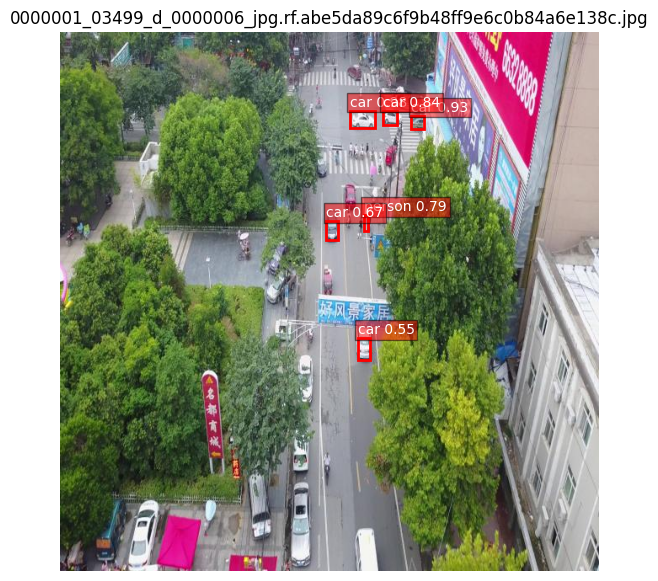

In [19]:
sample_img = os.path.join(images_path, os.listdir(images_path)[1])
img, boxes, confs, cids, idxs = run_yolo_visdrone(sample_img)

plt.figure(figsize=(7,7))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax = plt.gca()

if len(idxs) > 0:
    for i in idxs.flatten():
        x,y,w,h = boxes[i]
        cls = visdrone_classes[cids[i]]
        conf = confs[i]
        rect = plt.Rectangle((x,y), w, h, fill=False, linewidth=2, color='red')
        ax.add_patch(rect)
        ax.text(x, y-5, f"{cls} {conf:.2f}", color='white',
                bbox=dict(facecolor='red', alpha=0.5, pad=2))

plt.axis('off')
plt.title(os.path.basename(sample_img))
plt.show()

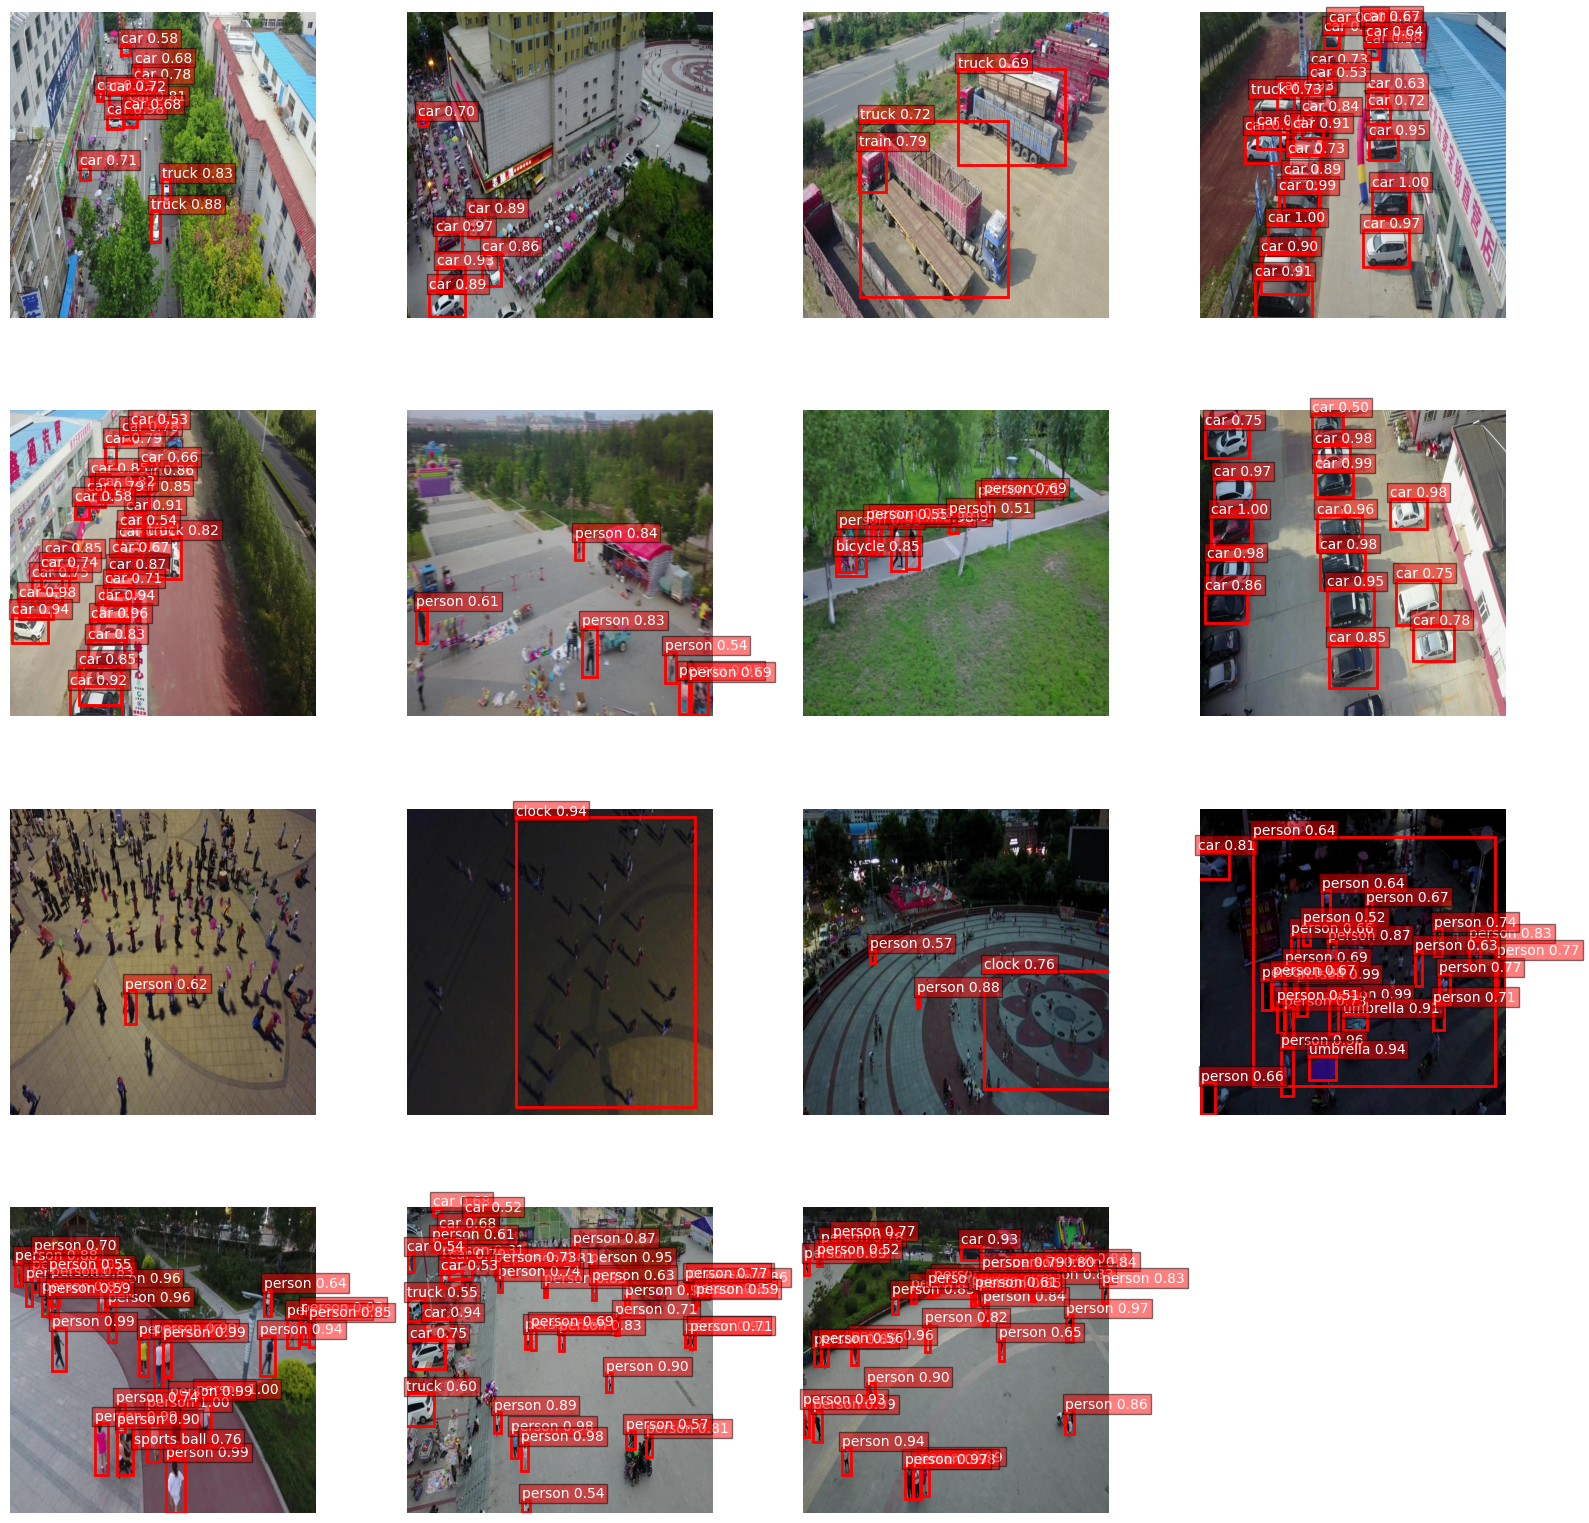

In [20]:
import matplotlib.pyplot as plt
import cv2
import os

image_files = os.listdir(images_path)
image_files = image_files[::10][:15]  
plt.figure(figsize=(16, 16))

for idx, img_file in enumerate(image_files):
    img_path = os.path.join(images_path, img_file)
    img, boxes, confs, cids, idxs = run_yolo_visdrone(img_path)

    plt.subplot(4, 4, idx + 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax = plt.gca()

    if len(idxs) > 0:
        for i in idxs.flatten():
            x, y, w, h = boxes[i]
            cls = visdrone_classes[cids[i]]
            conf = confs[i]
            rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=2, color='red')
            ax.add_patch(rect)
            ax.text(x, y - 5, f"{cls} {conf:.2f}", color='white',
                    bbox=dict(facecolor='red', alpha=0.5, pad=2))

    plt.axis('off')
    # Removed plt.title to hide image names

plt.tight_layout()
plt.show()


In [21]:
import tensorflow as tf
import os

images_dir = 'data/images'
labels_dir = 'data/labels'

def parse_example(image_path):
    image_name = tf.strings.split(image_path, os.sep)[-1]
    label_path = tf.strings.join([labels_dir, '/', tf.strings.regex_replace(image_name, '.jpg', '.txt')])
    
    # Load image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224]) / 255.0
    
    # Load label
    label_content = tf.io.read_file(label_path)
    label_lines = tf.strings.split(label_content, '\n')
    label_line = label_lines[0]  # For simplicity, take first object
    
    fields = tf.strings.to_number(tf.strings.split(label_line), out_type=tf.float32)
    class_id = tf.cast(fields[0], tf.int32)
    bbox = fields[1:]  # [x_center, y_center, width, height]
    
    return image, (bbox, class_id)

# Prepare dataset
image_paths = tf.data.Dataset.list_files(images_dir + '/*.jpg')
dataset = image_paths.map(parse_example).shuffle(1000).batch(32).prefetch(tf.data.AUTOTUNE)


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import os

# Paths
images_dir = 'data/images'
labels_dir = 'data/labels'

# Load Data
image_paths = []
labels = []

for filename in os.listdir(labels_dir):
    with open(os.path.join(labels_dir, filename), 'r') as f:
        first_label = int(f.readline().split()[0])  # Only first class
    image_name = filename.replace('.txt', '.jpg')  # or .png
    image_paths.append(os.path.join(images_dir, image_name))
    labels.append(first_label)

# Dataset Preparation
AUTOTUNE = tf.data.AUTOTUNE

def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    return image, label

dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
dataset = dataset.map(load_image, num_parallel_calls=AUTOTUNE)
dataset = dataset.shuffle(buffer_size=1000).batch(32).prefetch(AUTOTUNE)

# CNN Model
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(len(set(labels)), activation='softmax')  # output classes
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(dataset, epochs=10)


Epoch 1/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.4068 - loss: 228.0036
Epoch 2/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.5048 - loss: 1.5316
Epoch 3/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 293s 1s/step - accuracy: 0.6431 - loss: 1.0795
Epoch 4/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 266s 980ms/step - accuracy: 0.8076 - loss: 0.6004
Epoch 5/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 274s 1s/step - accuracy: 0.9284 - loss: 0.2608
Epoch 6/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.9628 - loss: 0.1464
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.9741 - loss: 0.1025
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 273s 1s/step - accuracy: 0.9750 - loss: 0.1432
Epoch 9/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 275s 1s/step - accuracy: 0.9713 - loss: 0.1278
Epoch 10/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 277s 1s/step - accuracy: 0.9815 - loss: 0.0749


In [8]:
model.save('model.h5')

In [18]:
model.save('my_model.keras')

In [17]:
import matplotlib.pyplot as plt

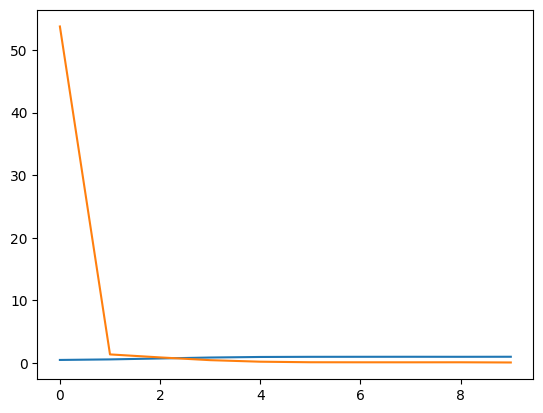

In [ ]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['loss'])

In [20]:
from tensorflow.keras.models import load_model

model = load_model('my_model.keras')

In [ ]:
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])
    return image

In [29]:
df['class_name'].unique()

array(['pedestrian', 'people', 'motor', 'car', 'awning-tricycle',
       'object', 'van', 'bicycle', 'truck', 'bus', 'others', 'tricycle'],
      dtype=object)

In [32]:
import tensorflow as tf
import numpy as np

# Load the trained model
model = tf.keras.models.load_model('my_model.keras')

# Class labels (update this according to your dataset)
class_names = ['pedestrian', 'people', 'motor', 'car', 'awning-tricycle',
       'object', 'van', 'bicycle', 'truck', 'bus', 'others', 'tricycle']  

def predict_image(image_path):
    # Load and preprocess image
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [224, 224])  # Same size as training
    image = image / 255.0  # Normalization if applied during training
    image = tf.expand_dims(image, axis=0)  # Batch dimension

    # Predict
    predictions = model.predict(image)
    predicted_class = np.argmax(predictions[0])
    confidence = predictions[0][predicted_class]

    print(f"Predicted Class: {class_names[predicted_class]} ({confidence:.2f} confidence)")
    return class_names[predicted_class], confidence


In [33]:
predict_image("data\\images\\0000001_02999_d_0000005_jpg.rf.7d2167b51ad201771c58205f7686c4e6.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted Class: car (0.49 confidence)


('car', np.float32(0.4856956))

# Multiple bounding boxes

In [80]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses
import os
import glob
import numpy as np

# Constants
IMAGE_SIZE = 224
NUM_CLASSES = 11
NUM_BOXES = 5  # Max number of objects per image
INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)
LABEL_VECTOR_SIZE = 4 + NUM_CLASSES  # bbox (4) + class one-hot

images_dir = 'data/images'
labels_dir = 'labels'

def custom_yolo_loss(y_true, y_pred):
    # Split bbox and class parts
    true_box = y_true[:, :, :4]
    true_class = y_true[:, :, 4:]

    pred_box = y_pred[:, :, :4]
    pred_class = y_pred[:, :, 4:]

    # MSE loss for bounding box coordinates
    bbox_loss = tf.reduce_mean(tf.square(true_box - pred_box))

    # Categorical cross-entropy for class prediction
    class_loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(true_class, pred_class, from_logits=True))

    return bbox_loss + class_loss

def find_matching_pairs():
    """
    Find all valid image-label pairs and return them as lists
    """
    image_files = glob.glob(os.path.join(images_dir, '*.jpg'))
    label_files = glob.glob(os.path.join(labels_dir, '*.txt'))
    
    print(f"Found {len(image_files)} image files")
    print(f"Found {len(label_files)} label files")
    
    # Show some examples to understand naming pattern
    print(f"\nSample image files:")
    for img in image_files[:3]:
        print(f"  {os.path.basename(img)}")
    
    print(f"\nSample label files:")
    for label in label_files[:3]:
        print(f"  {os.path.basename(label)}")
    
    # Create lookup for faster matching
    label_lookup = {}
    for label_path in label_files:
        label_name = os.path.basename(label_path)
        base_name = os.path.splitext(label_name)[0]  # Remove .txt
        label_lookup[base_name] = label_path
    
    valid_pairs = []
    missing_count = 0
    
    for img_path in image_files:
        img_name = os.path.basename(img_path)
        img_base = os.path.splitext(img_name)[0]  # Remove .jpg
        
        if img_base in label_lookup:
            valid_pairs.append((img_path, label_lookup[img_base]))
        else:
            missing_count += 1
            if missing_count <= 3:  # Show first few missing
                print(f"No label found for image: {img_name}")
    
    print(f"\nFound {len(valid_pairs)} valid image-label pairs")
    print(f"Missing labels for {missing_count} images")
    
    if len(valid_pairs) == 0:
        raise ValueError("No matching image-label pairs found!")
    
    return valid_pairs

def load_and_parse_label_file(label_path):
    """
    Load and parse a label file, return numpy array
    """
    try:
        # Read the file content
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        boxes = []
        for line in lines:
            line = line.strip()
            if line:  # Skip empty lines
                parts = line.split()
                if len(parts) >= 5:  # class_id + 4 bbox coordinates
                    class_id = int(float(parts[0]))
                    bbox = [float(x) for x in parts[1:5]]  # [x_center, y_center, width, height]
                    
                    # Create one-hot encoding
                    one_hot = np.zeros(NUM_CLASSES)
                    if 0 <= class_id < NUM_CLASSES:
                        one_hot[class_id] = 1
                    
                    # Combine bbox and one-hot
                    label_vector = np.concatenate([bbox, one_hot])
                    boxes.append(label_vector)
        
        # Convert to numpy array and pad/truncate to NUM_BOXES
        if len(boxes) == 0:
            # Return empty boxes if no valid annotations
            return np.zeros((NUM_BOXES, LABEL_VECTOR_SIZE), dtype=np.float32)
        
        boxes = np.array(boxes, dtype=np.float32)
        
        # Pad or truncate to NUM_BOXES
        if len(boxes) < NUM_BOXES:
            padding = np.zeros((NUM_BOXES - len(boxes), LABEL_VECTOR_SIZE), dtype=np.float32)
            boxes = np.vstack([boxes, padding])
        else:
            boxes = boxes[:NUM_BOXES]
        
        return boxes
        
    except Exception as e:
        print(f"Error reading label file {label_path}: {e}")
        return np.zeros((NUM_BOXES, LABEL_VECTOR_SIZE), dtype=np.float32)

def create_dataset_from_pairs(valid_pairs):
    """
    Create TensorFlow dataset from valid pairs
    """
    print(f"Creating dataset from {len(valid_pairs)} pairs...")
    
    # Pre-load all data into memory to avoid file I/O during training
    images_list = []
    labels_list = []
    
    for i, (img_path, label_path) in enumerate(valid_pairs):
        if i % 1000 == 0:
            print(f"Processing {i}/{len(valid_pairs)}...")
        
        try:
            # Load image
            img = tf.io.read_file(img_path)
            img = tf.image.decode_jpeg(img, channels=3)
            img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
            img = tf.cast(img, tf.float32) / 255.0
            
            # Load label
            label = load_and_parse_label_file(label_path)
            
            images_list.append(img.numpy())
            labels_list.append(label)
            
        except Exception as e:
            print(f"Error processing pair {img_path}, {label_path}: {e}")
            continue
    
    if len(images_list) == 0:
        raise ValueError("No valid data could be loaded!")
    
    print(f"Successfully loaded {len(images_list)} samples")
    
    # Convert to numpy arrays
    images_array = np.array(images_list)
    labels_array = np.array(labels_list)
    
    print(f"Images shape: {images_array.shape}")
    print(f"Labels shape: {labels_array.shape}")
    
    # Create TensorFlow dataset from numpy arrays
    dataset = tf.data.Dataset.from_tensor_slices((images_array, labels_array))
    dataset = dataset.shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)
    
    return dataset

def build_tiny_yolo_model():
    inputs = layers.Input(shape=INPUT_SHAPE)
    
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(NUM_BOXES * LABEL_VECTOR_SIZE)(x)
    outputs = layers.Reshape((NUM_BOXES, LABEL_VECTOR_SIZE))(x)

    return models.Model(inputs, outputs)

# Main execution
try:
    print("Step 1: Finding matching image-label pairs...")
    valid_pairs = find_matching_pairs()
    
    print(f"\nStep 2: Creating dataset...")
    dataset = create_dataset_from_pairs(valid_pairs)
    
    print(f"\nStep 3: Testing dataset...")
    for batch in dataset.take(1):
        images, labels = batch
        print(f"Batch shapes - Images: {images.shape}, Labels: {labels.shape}")
        print(f"Image value range: {tf.reduce_min(images):.3f} to {tf.reduce_max(images):.3f}")
        print(f"Labels value range: {tf.reduce_min(labels):.3f} to {tf.reduce_max(labels):.3f}")
        break
    
    print(f"\nStep 4: Building model...")
    model = build_tiny_yolo_model()
    model.summary()
    
    model.compile(optimizer='adam', loss=custom_yolo_loss)
    
    print("\n✅ Everything ready for training!")
    print("To start training, uncomment the next line:")
    print("# model.fit(dataset, epochs=10)")
    
    # Uncomment to start training:
    # model.fit(dataset, epochs=10)
    
except Exception as e:
    print(f"❌ Error: {str(e)}")
    import traceback
    traceback.print_exc()

Step 1: Finding matching image-label pairs...
Found 8626 image files
Found 8626 label files

Sample image files:
  0000001_02999_d_0000005_jpg.rf.7d2167b51ad201771c58205f7686c4e6.jpg
  0000001_03499_d_0000006_jpg.rf.abe5da89c6f9b48ff9e6c0b84a6e138c.jpg
  0000001_03999_d_0000007_jpg.rf.73f39b4ea03ce82c266f7ee1f426a1fd.jpg

Sample label files:
  0000001_02999_d_0000005_jpg.rf.7d2167b51ad201771c58205f7686c4e6.txt
  0000001_03499_d_0000006_jpg.rf.abe5da89c6f9b48ff9e6c0b84a6e138c.txt
  0000001_03999_d_0000007_jpg.rf.73f39b4ea03ce82c266f7ee1f426a1fd.txt

Found 8626 valid image-label pairs
Missing labels for 0 images

Step 2: Creating dataset...
Creating dataset from 8626 pairs...
Processing 0/8626...
Processing 1000/8626...
Processing 2000/8626...
Processing 3000/8626...
Processing 4000/8626...
Processing 5000/8626...
Processing 6000/8626...
Processing 7000/8626...
Processing 8000/8626...
Successfully loaded 8626 samples
Images shape: (8626, 224, 224, 3)
Labels shape: (8626, 5, 15)

Step 3: 

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 75)             │         9,675 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_9 (Reshape)             │ (None, 5, 15)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,579 (162.42 KB)

 Trainable params: 41,579 (162.42 KB)

 Non-trainable params: 0 (0.00 B)


✅ Everything ready for training!
To start training, uncomment the next line:
# model.fit(dataset, epochs=10)


In [81]:
model.fit(dataset, epochs=10)

Epoch 1/10


KeyboardInterrupt: 

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, losses
import os
import glob
import numpy as np

# Constants
IMAGE_SIZE = 224
NUM_CLASSES = 11
NUM_BOXES = 5  # Max number of objects per image
INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)
LABEL_VECTOR_SIZE = 4 + NUM_CLASSES  # bbox (4) + class one-hot

images_dir = 'data/images'
labels_dir = 'labels'

def custom_yolo_loss(y_true, y_pred):
    # Split bbox and class parts
    true_box = y_true[:, :, :4]
    true_class = y_true[:, :, 4:]

    pred_box = y_pred[:, :, :4]
    pred_class = y_pred[:, :, 4:]

    # MSE loss for bounding box coordinates
    bbox_loss = tf.reduce_mean(tf.square(true_box - pred_box))

    # Categorical cross-entropy for class prediction
    class_loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(true_class, pred_class, from_logits=True))

    return bbox_loss + class_loss

def find_matching_pairs():
    """
    Find all valid image-label pairs and return them as lists
    """
    image_files = glob.glob(os.path.join(images_dir, '*.jpg'))
    label_files = glob.glob(os.path.join(labels_dir, '*.txt'))
    
    print(f"Found {len(image_files)} image files")
    print(f"Found {len(label_files)} label files")
    
    # Show some examples to understand naming pattern
    print(f"\nSample image files:")
    for img in image_files[:3]:
        print(f"  {os.path.basename(img)}")
    
    print(f"\nSample label files:")
    for label in label_files[:3]:
        print(f"  {os.path.basename(label)}")
    
    # Create lookup for faster matching
    label_lookup = {}
    for label_path in label_files:
        label_name = os.path.basename(label_path)
        base_name = os.path.splitext(label_name)[0]  # Remove .txt
        label_lookup[base_name] = label_path
    
    valid_pairs = []
    missing_count = 0
    
    for img_path in image_files:
        img_name = os.path.basename(img_path)
        img_base = os.path.splitext(img_name)[0]  # Remove .jpg
        
        if img_base in label_lookup:
            valid_pairs.append((img_path, label_lookup[img_base]))
        else:
            missing_count += 1
            if missing_count <= 3:  # Show first few missing
                print(f"No label found for image: {img_name}")
    
    print(f"\nFound {len(valid_pairs)} valid image-label pairs")
    print(f"Missing labels for {missing_count} images")
    
    if len(valid_pairs) == 0:
        raise ValueError("No matching image-label pairs found!")
    
    return valid_pairs

def load_and_parse_label_file(label_path):
    """
    Load and parse a label file, return numpy array
    """
    try:
        # Read the file content
        with open(label_path, 'r') as f:
            lines = f.readlines()
        
        boxes = []
        for line in lines:
            line = line.strip()
            if line:  # Skip empty lines
                parts = line.split()
                if len(parts) >= 5:  # class_id + 4 bbox coordinates
                    class_id = int(float(parts[0]))
                    bbox = [float(x) for x in parts[1:5]]  # [x_center, y_center, width, height]
                    
                    # Create one-hot encoding
                    one_hot = np.zeros(NUM_CLASSES)
                    if 0 <= class_id < NUM_CLASSES:
                        one_hot[class_id] = 1
                    
                    # Combine bbox and one-hot
                    label_vector = np.concatenate([bbox, one_hot])
                    boxes.append(label_vector)
        
        # Convert to numpy array and pad/truncate to NUM_BOXES
        if len(boxes) == 0:
            # Return empty boxes if no valid annotations
            return np.zeros((NUM_BOXES, LABEL_VECTOR_SIZE), dtype=np.float32)
        
        boxes = np.array(boxes, dtype=np.float32)
        
        # Pad or truncate to NUM_BOXES
        if len(boxes) < NUM_BOXES:
            padding = np.zeros((NUM_BOXES - len(boxes), LABEL_VECTOR_SIZE), dtype=np.float32)
            boxes = np.vstack([boxes, padding])
        else:
            boxes = boxes[:NUM_BOXES]
        
        return boxes
        
    except Exception as e:
        print(f"Error reading label file {label_path}: {e}")
        return np.zeros((NUM_BOXES, LABEL_VECTOR_SIZE), dtype=np.float32)

def create_dataset_from_pairs(valid_pairs, val_split=0.2):
    """
    Create TensorFlow training and validation datasets from valid pairs
    """
    print(f"Creating dataset from {len(valid_pairs)} pairs...")
    
    # Shuffle the pairs for random train/val split
    import random
    random.shuffle(valid_pairs)
    
    # Calculate split point
    split_idx = int(len(valid_pairs) * (1 - val_split))
    train_pairs = valid_pairs[:split_idx]
    val_pairs = valid_pairs[split_idx:]
    
    print(f"Train samples: {len(train_pairs)}")
    print(f"Validation samples: {len(val_pairs)}")
    
    def load_data_from_pairs(pairs, split_name):
        """Helper function to load data from pairs"""
        images_list = []
        labels_list = []
        
        for i, (img_path, label_path) in enumerate(pairs):
            if i % 1000 == 0:
                print(f"Processing {split_name} {i}/{len(pairs)}...")
            
            try:
                # Load image
                img = tf.io.read_file(img_path)
                img = tf.image.decode_jpeg(img, channels=3)
                img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
                img = tf.cast(img, tf.float32) / 255.0
                
                # Load label
                label = load_and_parse_label_file(label_path)
                
                images_list.append(img.numpy())
                labels_list.append(label)
                
            except Exception as e:
                print(f"Error processing pair {img_path}, {label_path}: {e}")
                continue
        
        if len(images_list) == 0:
            raise ValueError(f"No valid data could be loaded for {split_name}!")
        
        print(f"Successfully loaded {len(images_list)} {split_name} samples")
        
        # Convert to numpy arrays
        images_array = np.array(images_list)
        labels_array = np.array(labels_list)
        
        return images_array, labels_array
    
    # Load training data
    train_images, train_labels = load_data_from_pairs(train_pairs, "train")
    
    # Load validation data
    val_images, val_labels = load_data_from_pairs(val_pairs, "validation")
    
    print(f"\nDataset Summary:")
    print(f"Train - Images: {train_images.shape}, Labels: {train_labels.shape}")
    print(f"Val   - Images: {val_images.shape}, Labels: {val_labels.shape}")
    
    # Create TensorFlow datasets
    train_dataset = tf.data.Dataset.from_tensor_slices((train_images, train_labels))
    train_dataset = train_dataset.shuffle(500).batch(32).prefetch(tf.data.AUTOTUNE)
    
    val_dataset = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
    val_dataset = val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
    
    return train_dataset, val_dataset

def build_tiny_yolo_model():
    inputs = layers.Input(shape=INPUT_SHAPE)
    
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(NUM_BOXES * LABEL_VECTOR_SIZE)(x)
    outputs = layers.Reshape((NUM_BOXES, LABEL_VECTOR_SIZE))(x)

    return models.Model(inputs, outputs)

# Main execution
try:
    print("Step 1: Finding matching image-label pairs...")
    valid_pairs = find_matching_pairs()
    
    print(f"\nStep 2: Creating train/validation datasets...")
    train_dataset, val_dataset = create_dataset_from_pairs(valid_pairs, val_split=0.2)
    
    print(f"\nStep 3: Testing datasets...")
    # Test training dataset
    for batch in train_dataset.take(1):
        images, labels = batch
        print(f"Train batch shapes - Images: {images.shape}, Labels: {labels.shape}")
        print(f"Image value range: {tf.reduce_min(images):.3f} to {tf.reduce_max(images):.3f}")
        print(f"Labels value range: {tf.reduce_min(labels):.3f} to {tf.reduce_max(labels):.3f}")
        break
    
    # Test validation dataset
    for batch in val_dataset.take(1):
        images, labels = batch
        print(f"Val batch shapes - Images: {images.shape}, Labels: {labels.shape}")
        break
    
    print(f"\nStep 4: Building model...")
    model = build_tiny_yolo_model()
    model.summary()
    
    model.compile(
        optimizer='adam', 
        loss=custom_yolo_loss,
        metrics=['mae']  # Add metrics for monitoring
    )
    
    print("\n✅ Everything ready for training!")
    print("To start training with validation, uncomment the next line:")
    print("# history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)")
    
    history = model.fit(
        train_dataset, 
        validation_data=val_dataset, 
        epochs=10,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5)
        ]
    )
    
except Exception as e:
    print(f"❌ Error: {str(e)}")
    import traceback
    traceback.print_exc()

Step 1: Finding matching image-label pairs...
Found 8626 image files
Found 8626 label files

Sample image files:
  0000001_02999_d_0000005_jpg.rf.7d2167b51ad201771c58205f7686c4e6.jpg
  0000001_03499_d_0000006_jpg.rf.abe5da89c6f9b48ff9e6c0b84a6e138c.jpg
  0000001_03999_d_0000007_jpg.rf.73f39b4ea03ce82c266f7ee1f426a1fd.jpg

Sample label files:
  0000001_02999_d_0000005_jpg.rf.7d2167b51ad201771c58205f7686c4e6.txt
  0000001_03499_d_0000006_jpg.rf.abe5da89c6f9b48ff9e6c0b84a6e138c.txt
  0000001_03999_d_0000007_jpg.rf.73f39b4ea03ce82c266f7ee1f426a1fd.txt

Found 8626 valid image-label pairs
Missing labels for 0 images

Step 2: Creating train/validation datasets...
Creating dataset from 8626 pairs...
Train samples: 6900
Validation samples: 1726
Processing train 0/6900...
Processing train 1000/6900...
Processing train 2000/6900...
Processing train 3000/6900...
Processing train 4000/6900...
Processing train 5000/6900...
Processing train 6000/6900...
Successfully loaded 6900 train samples
Processi

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 75)             │         9,675 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_10 (Reshape)            │ (None, 5, 15)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,579 (162.42 KB)

 Trainable params: 41,579 (162.42 KB)

 Non-trainable params: 0 (0.00 B)


✅ Everything ready for training!
To start training with validation, uncomment the next line:
# history = model.fit(train_dataset, validation_data=val_dataset, epochs=10)
Epoch 1/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 85s 359ms/step - loss: 1.7475 - mae: 3.2785 - val_loss: 11.0933 - val_mae: 252.9591 - learning_rate: 0.0010
Epoch 2/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 75s 346ms/step - loss: 41.3917 - mae: 773.6825 - val_loss: 33.6782 - val_mae: 2090.5977 - learning_rate: 0.0010
Epoch 3/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 76s 349ms/step - loss: 143.7514 - mae: 2906.4272 - val_loss: 122.4709 - val_mae: 4869.4043 - learning_rate: 0.0010
Epoch 4/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 82s 381ms/step - loss: 99.2393 - mae: 6184.4658 - val_loss: 131.3476 - val_mae: 10401.9668 - learning_rate: 5.0000e-04


In [83]:
def improved_yolo_loss(y_true, y_pred):
    """
    Improved YOLO loss with better weighting and gradient clipping
    """
    # Split bbox and class parts
    true_box = y_true[:, :, :4]
    true_class = y_true[:, :, 4:]
    
    pred_box = y_pred[:, :, :4]
    pred_class = y_pred[:, :, 4:]
    
    # Create object mask (where there are actual objects)
    # An object exists if any class is 1 (not all zeros)
    object_mask = tf.reduce_max(true_class, axis=-1, keepdims=True)  # Shape: (batch, boxes, 1)
    
    # Bounding box loss (only for cells with objects)
    bbox_mse = tf.square(true_box - pred_box)
    bbox_loss = tf.reduce_sum(bbox_mse * object_mask) / (tf.reduce_sum(object_mask) + 1e-6)
    
    # Classification loss (for all cells, but weighted)
    # Use sigmoid instead of softmax for multi-class detection
    pred_class_sigmoid = tf.sigmoid(pred_class)
    class_loss = tf.keras.losses.binary_crossentropy(true_class, pred_class_sigmoid)
    class_loss = tf.reduce_mean(class_loss)
    
    # Weight the losses appropriately
    total_loss = 5.0 * bbox_loss + 1.0 * class_loss
    
    # Clip gradients to prevent explosion
    total_loss = tf.clip_by_value(total_loss, 0.0, 100.0)
    
    return total_loss

def bbox_mae_metric(y_true, y_pred):
    """
    Calculate MAE only for bounding box coordinates of objects that exist
    """
    true_box = y_true[:, :, :4]
    true_class = y_true[:, :, 4:]
    pred_box = y_pred[:, :, :4]
    
    # Object mask
    object_mask = tf.reduce_max(true_class, axis=-1, keepdims=True)
    
    # MAE only for existing objects
    bbox_mae = tf.abs(true_box - pred_box)
    masked_mae = bbox_mae * object_mask
    
    return tf.reduce_sum(masked_mae) / (tf.reduce_sum(object_mask) + 1e-6)

def class_accuracy_metric(y_true, y_pred):
    """
    Calculate classification accuracy for existing objects
    """
    true_class = y_true[:, :, 4:]
    pred_class = tf.sigmoid(y_pred[:, :, 4:])
    
    # Object mask
    object_mask = tf.reduce_max(true_class, axis=-1)  # Shape: (batch, boxes)
    
    # Get predicted class (argmax)
    true_class_idx = tf.argmax(true_class, axis=-1)
    pred_class_idx = tf.argmax(pred_class, axis=-1)
    
    # Accuracy only for existing objects
    correct_predictions = tf.cast(tf.equal(true_class_idx, pred_class_idx), tf.float32)
    masked_accuracy = correct_predictions * object_mask
    
    return tf.reduce_sum(masked_accuracy) / (tf.reduce_sum(object_mask) + 1e-6)

def objectness_score_metric(y_true, y_pred):
    """
    Additional metric: How well the model detects object presence
    """
    true_class = y_true[:, :, 4:]
    pred_class = tf.sigmoid(y_pred[:, :, 4:])
    
    # True objectness (1 if any class is active, 0 otherwise)
    true_objectness = tf.cast(tf.reduce_max(true_class, axis=-1) > 0.5, tf.float32)
    
    # Predicted objectness (max class probability)
    pred_objectness = tf.reduce_max(pred_class, axis=-1)
    
    # Binary accuracy for object detection
    pred_binary = tf.cast(pred_objectness > 0.5, tf.float32)
    accuracy = tf.reduce_mean(tf.cast(tf.equal(true_objectness, pred_binary), tf.float32))
    
    return accuracy

def build_improved_yolo_model():
    """
    Build a more stable YOLO model with better initialization and regularization
    """
    inputs = layers.Input(shape=INPUT_SHAPE)
    
    # Use He initialization and batch normalization
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same', 
                      kernel_initializer='he_normal')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)
    
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                      kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu', kernel_initializer='he_normal')(x)
    x = layers.Dropout(0.3)(x)
    
    # Initialize final layer with smaller weights
    x = layers.Dense(NUM_BOXES * LABEL_VECTOR_SIZE, 
                     kernel_initializer=tf.keras.initializers.RandomNormal(stddev=0.01),
                     bias_initializer='zeros')(x)
    outputs = layers.Reshape((NUM_BOXES, LABEL_VECTOR_SIZE))(x)

    return models.Model(inputs, outputs)

def compile_and_train_model(train_dataset, val_dataset, epochs=20):
    """
    Complete training function with improved configuration
    """
    print("Building improved model...")
    model = build_improved_yolo_model()
    model.summary()
    
    # Compile with improved loss and metrics
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),  # Lower learning rate
        loss=improved_yolo_loss,
        metrics=[bbox_mae_metric, class_accuracy_metric, objectness_score_metric]
    )
    
    print("\n🚀 Starting training with improved configuration...")
    
    # Define callbacks
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            patience=5, 
            restore_best_weights=True, 
            monitor='val_loss',
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            patience=3, 
            factor=0.5, 
            min_lr=1e-6, 
            monitor='val_loss',
            verbose=1
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'best_yolo_model.h5', 
            save_best_only=True, 
            monitor='val_loss',
            verbose=1
        )
    ]
    
    # Train the model
    history = model.fit(
        train_dataset, 
        validation_data=val_dataset, 
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )
    
    print("✅ Training completed!")
    return model, history

def evaluate_model_performance(model, val_dataset):
    """
    Evaluate model performance with detailed metrics
    """
    print("\n📊 Evaluating model performance...")
    
    # Get predictions on validation set
    val_loss, val_bbox_mae, val_class_acc, val_obj_score = model.evaluate(val_dataset, verbose=0)
    
    print(f"Validation Results:")
    print(f"  Loss: {val_loss:.4f}")
    print(f"  BBox MAE: {val_bbox_mae:.4f}")
    print(f"  Class Accuracy: {val_class_acc:.4f}")
    print(f"  Objectness Score: {val_obj_score:.4f}")
    
    return {
        'loss': val_loss,
        'bbox_mae': val_bbox_mae,
        'class_accuracy': val_class_acc,
        'objectness_score': val_obj_score
    }

def plot_training_history(history):
    """
    Plot training history for analysis
    """
    import matplotlib.pyplot as plt
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0, 0].plot(history.history['loss'], label='Train Loss')
    axes[0, 0].plot(history.history['val_loss'], label='Val Loss')
    axes[0, 0].set_title('Model Loss')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    
    # BBox MAE
    axes[0, 1].plot(history.history['bbox_mae_metric'], label='Train BBox MAE')
    axes[0, 1].plot(history.history['val_bbox_mae_metric'], label='Val BBox MAE')
    axes[0, 1].set_title('Bounding Box MAE')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('MAE')
    axes[0, 1].legend()
    
    # Class Accuracy
    axes[1, 0].plot(history.history['class_accuracy_metric'], label='Train Class Acc')
    axes[1, 0].plot(history.history['val_class_accuracy_metric'], label='Val Class Acc')
    axes[1, 0].set_title('Classification Accuracy')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].legend()
    
    # Objectness Score
    axes[1, 1].plot(history.history['objectness_score_metric'], label='Train Obj Score')
    axes[1, 1].plot(history.history['val_objectness_score_metric'], label='Val Obj Score')
    axes[1, 1].set_title('Objectness Detection')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].legend()
    
    plt.tight_layout()
    plt.show()

# Example usage (assuming you already have train_dataset and val_dataset):

Building improved model...


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 75)             │         9,675 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_11 (Reshape)            │ (None, 5, 15)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,027 (164.17 KB)

 Trainable params: 41,803 (163.29 KB)

...

216/216 ━━━━━━━━━━━━━━━━━━━━ 173s 801ms/step - bbox_mae_metric: 0.4987 - class_accuracy_metric: 0.5574 - loss: 0.9195 - objectness_score_metric: 0.5564 - val_bbox_mae_metric: 0.4936 - val_class_accuracy_metric: 0.5630 - val_loss: 0.9041 - val_objectness_score_metric: 0.4949 - learning_rate: 1.0000e-04
Epoch 6/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - bbox_mae_metric: 0.4952 - class_accuracy_metric: 0.5575 - loss: 0.9065 - objectness_score_metric: 0.5648
Epoch 6: val_loss improved from 0.90410 to 0.89062, saving model to best_yolo_model.h5


216/216 ━━━━━━━━━━━━━━━━━━━━ 173s 802ms/step - bbox_mae_metric: 0.4952 - class_accuracy_metric: 0.5575 - loss: 0.9064 - objectness_score_metric: 0.5649 - val_bbox_mae_metric: 0.4906 - val_class_accuracy_metric: 0.5630 - val_loss: 0.8906 - val_objectness_score_metric: 0.5036 - learning_rate: 1.0000e-04
Epoch 7/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 773ms/step - bbox_mae_metric: 0.4934 - class_accuracy_metric: 0.5530 - loss: 0.8999 - objectness_score_metric: 0.5453
Epoch 7: val_loss did not improve from 0.89062
216/216 ━━━━━━━━━━━━━━━━━━━━ 175s 810ms/step - bbox_mae_metric: 0.4934 - class_accuracy_metric: 0.5530 - loss: 0.8998 - objectness_score_metric: 0.5454 - val_bbox_mae_metric: 0.5003 - val_class_accuracy_metric: 0.5630 - val_loss: 0.9301 - val_objectness_score_metric: 0.5230 - learning_rate: 1.0000e-04
Epoch 8/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - bbox_mae_metric: 0.4932 - class_accuracy_metric: 0.5573 - loss: 0.8968 - objectness_score_metric: 0.5642
Epoch 8: val_loss did not

216/216 ━━━━━━━━━━━━━━━━━━━━ 173s 802ms/step - bbox_mae_metric: 0.4902 - class_accuracy_metric: 0.5584 - loss: 0.8866 - objectness_score_metric: 0.5531 - val_bbox_mae_metric: 0.4874 - val_class_accuracy_metric: 0.5630 - val_loss: 0.8865 - val_objectness_score_metric: 0.5120 - learning_rate: 5.0000e-05
Epoch 11/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - bbox_mae_metric: 0.4855 - class_accuracy_metric: 0.5607 - loss: 0.8761 - objectness_score_metric: 0.5527
Epoch 11: val_loss did not improve from 0.88648
216/216 ━━━━━━━━━━━━━━━━━━━━ 173s 800ms/step - bbox_mae_metric: 0.4855 - class_accuracy_metric: 0.5607 - loss: 0.8761 - objectness_score_metric: 0.5527 - val_bbox_mae_metric: 0.4912 - val_class_accuracy_metric: 0.5630 - val_loss: 0.8944 - val_objectness_score_metric: 0.5292 - learning_rate: 5.0000e-05
Epoch 12/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 762ms/step - bbox_mae_metric: 0.4877 - class_accuracy_metric: 0.5540 - loss: 0.8806 - objectness_score_metric: 0.5590
Epoch 12: val_loss imp

216/216 ━━━━━━━━━━━━━━━━━━━━ 173s 799ms/step - bbox_mae_metric: 0.4877 - class_accuracy_metric: 0.5541 - loss: 0.8806 - objectness_score_metric: 0.5590 - val_bbox_mae_metric: 0.4900 - val_class_accuracy_metric: 0.5630 - val_loss: 0.8863 - val_objectness_score_metric: 0.5067 - learning_rate: 5.0000e-05
Epoch 13/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 766ms/step - bbox_mae_metric: 0.4871 - class_accuracy_metric: 0.5559 - loss: 0.8790 - objectness_score_metric: 0.5399
Epoch 13: val_loss did not improve from 0.88626
216/216 ━━━━━━━━━━━━━━━━━━━━ 173s 799ms/step - bbox_mae_metric: 0.4870 - class_accuracy_metric: 0.5559 - loss: 0.8790 - objectness_score_metric: 0.5399 - val_bbox_mae_metric: 0.4895 - val_class_accuracy_metric: 0.5630 - val_loss: 0.8904 - val_objectness_score_metric: 0.5328 - learning_rate: 5.0000e-05
Epoch 14/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - bbox_mae_metric: 0.4865 - class_accuracy_metric: 0.5541 - loss: 0.8782 - objectness_score_metric: 0.5507
Epoch 14: val_loss improv

216/216 ━━━━━━━━━━━━━━━━━━━━ 306s 1s/step - bbox_mae_metric: 0.4865 - class_accuracy_metric: 0.5541 - loss: 0.8782 - objectness_score_metric: 0.5508 - val_bbox_mae_metric: 0.4861 - val_class_accuracy_metric: 0.5630 - val_loss: 0.8778 - val_objectness_score_metric: 0.5078 - learning_rate: 5.0000e-05
Epoch 15/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - bbox_mae_metric: 0.4889 - class_accuracy_metric: 0.5580 - loss: 0.8829 - objectness_score_metric: 0.5475
Epoch 15: val_loss did not improve from 0.87776
216/216 ━━━━━━━━━━━━━━━━━━━━ 339s 2s/step - bbox_mae_metric: 0.4888 - class_accuracy_metric: 0.5580 - loss: 0.8829 - objectness_score_metric: 0.5476 - val_bbox_mae_metric: 0.4890 - val_class_accuracy_metric: 0.5630 - val_loss: 0.8881 - val_objectness_score_metric: 0.5283 - learning_rate: 5.0000e-05
Epoch 16/20
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - bbox_mae_metric: 0.4845 - class_accuracy_metric: 0.5587 - loss: 0.8704 - objectness_score_metric: 0.5553
Epoch 16: val_loss did not improve

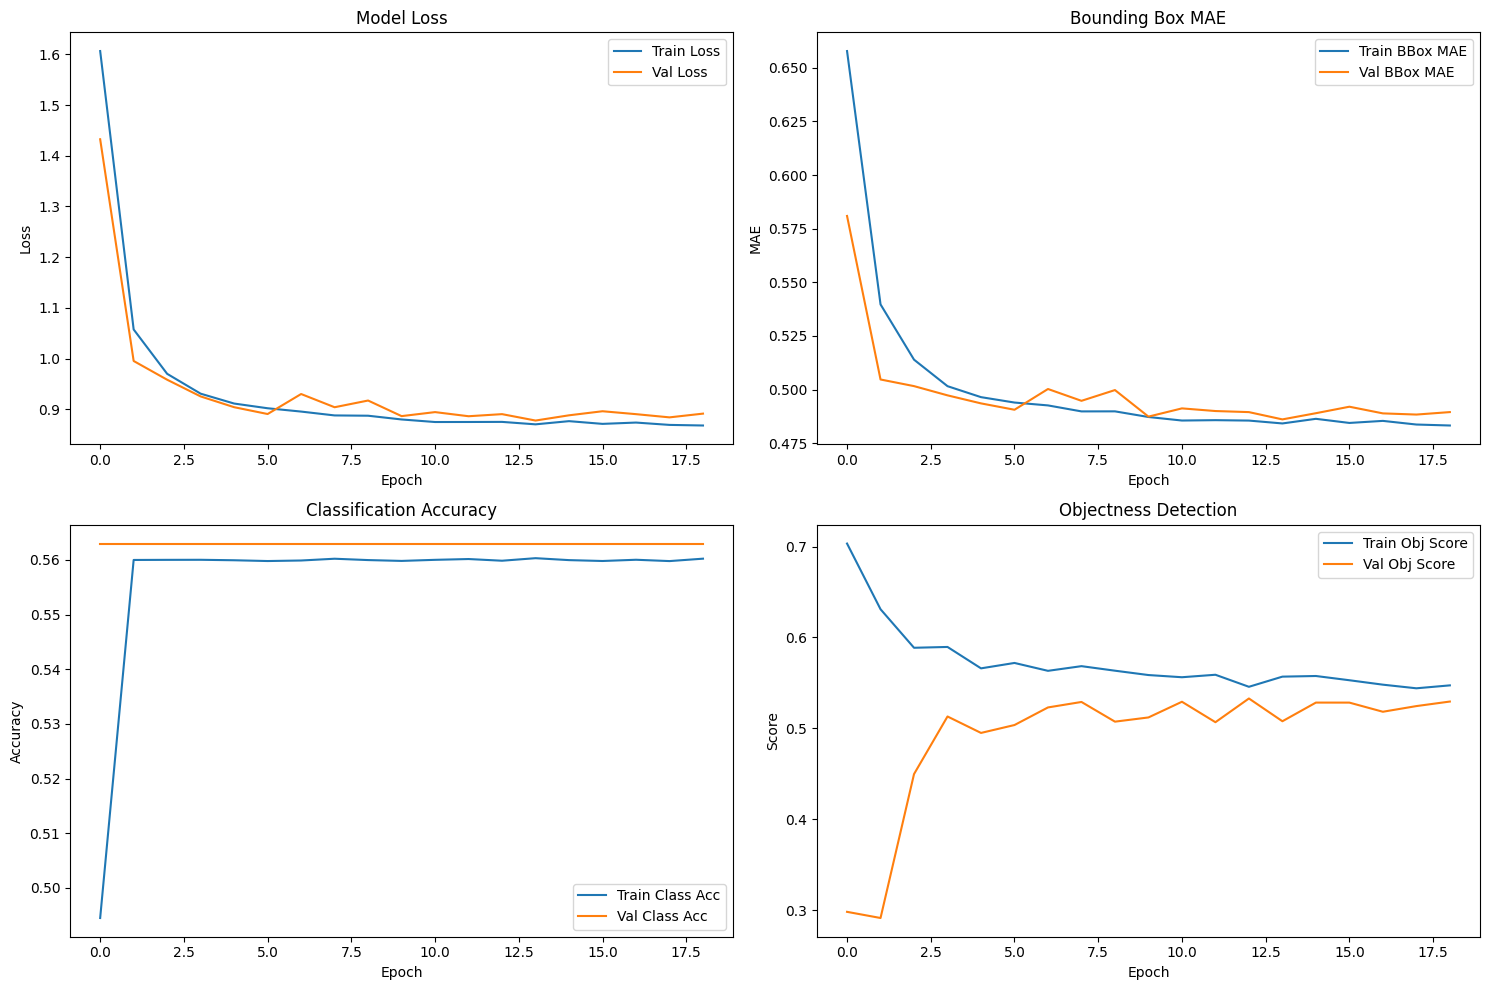

In [84]:
# Train the model
model, history = compile_and_train_model(train_dataset, val_dataset, epochs=20)

# Evaluate performance
metrics = evaluate_model_performance(model, val_dataset)

# Plot training history
plot_training_history(history)

In [ ]:
1